# Yahoo Finance data and technical analysis

## Overview
This notebook downloads historical stock market data, computes stock market features, constructs prediction targets, performs data cleaning, and produces the final market dataset.

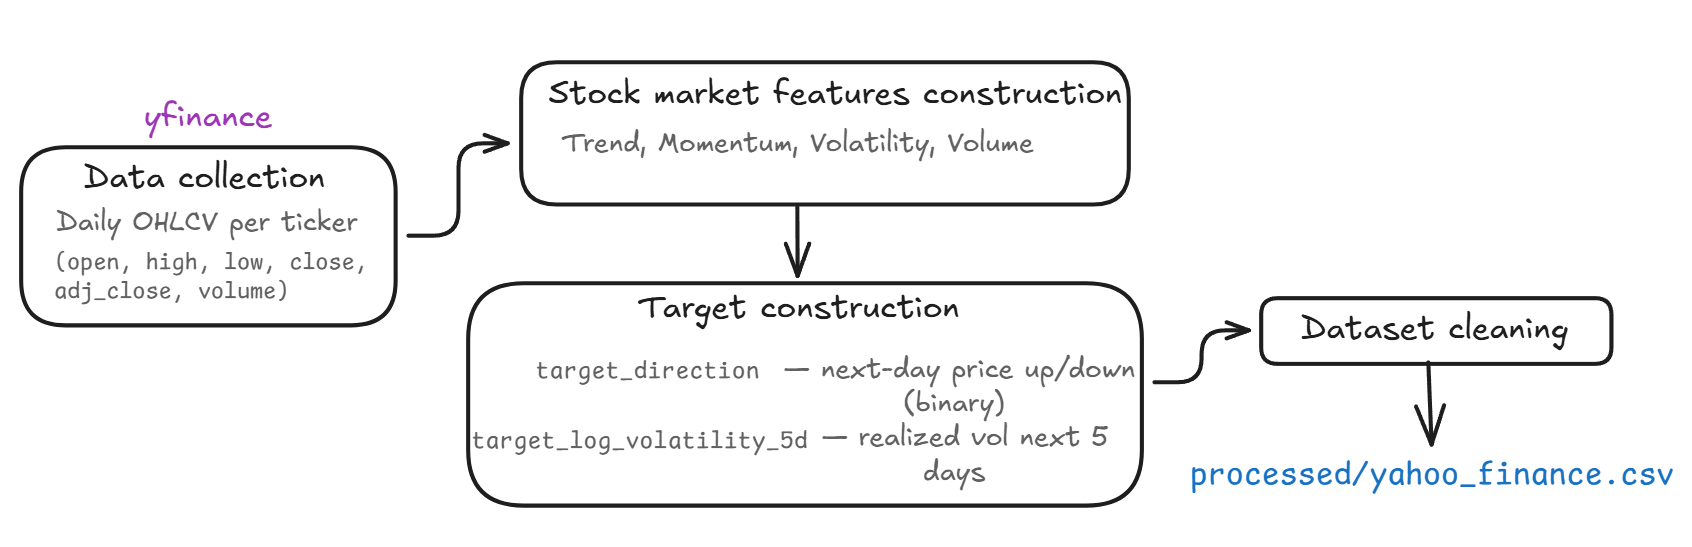

## 1. Configuration

In [1]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import mlflow
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats


TICKERS    = ["NVDA", "AMD", "INTC"]
START_DATE = "2016-03-31"
END_DATE = "2026-04-14"

OUTPUT_DIR = "datasets/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Data collection

Daily stock market data were downloaded from Yahoo Finance for NVIDIA (NVDA), AMD, and Intel (INTC) using the `yfinance` Python library. For each company, the dataset includes the opening price (`open`), highest price (`high`), lowest price (`low`), closing price (`close`) and trading volume (`volume`).


In [2]:
def download_price_data(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    """
    Download daily OHLCV data from Yahoo Finance for multiple tickers.

    Args:
        tickers : List of ticker symbols.
        start   : Start date string (YYYY-MM-DD).
        end     : End date string (YYYY-MM-DD).

    Returns:
        DataFrame with columns: date, ticker, open, high, low,
        close, volume.
    """
    all_data = []

    for ticker in tickers:
        print(f"Downloading {ticker}...")
        raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)

        if raw.empty:
            print(f"  No data returned for {ticker}.")
            continue

        raw = raw.reset_index()
        raw.columns = [col[0].lower() if isinstance(col, tuple) else col.lower()
                       for col in raw.columns]

        raw["ticker"] = ticker
        raw["date"]   = pd.to_datetime(raw["date"]).dt.date

        all_data.append(raw[["date", "ticker", "open", "high", "low","close", "volume"]])
        print(f"  {len(raw)} trading days downloaded.")

    df = pd.concat(all_data, ignore_index=True)
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
    return df


df_prices = download_price_data(TICKERS, START_DATE, END_DATE)

print(f"\nTotal rows : {len(df_prices)}")
print(f"Date range : {df_prices['date'].min()} to {df_prices['date'].max()}")
df_prices.head()

  2523 trading days downloaded.
  2523 trading days downloaded.
  2523 trading days downloaded.

Total rows : 7569
Date range : 2016-03-31 to 2026-04-13


,date,ticker,open,high,low,close,volume
0,2016-03-31,AMD,2.84,2.88,2.80,2.85,9071500
1,2016-04-01,AMD,2.79,2.88,2.76,2.83,8257700
2,2016-04-04,AMD,2.83,2.87,2.80,2.83,5591100
3,2016-04-05,AMD,2.76,2.84,2.72,2.76,9640200
4,2016-04-06,AMD,2.75,2.80,2.72,2.80,12534600


## 3. Stock market features construction

To enrich the raw market data with additional information about price behavior, a set of technical indicators and features inspired by HAR model were computed for each company. The selected indicators can be grouped into categories: trend, momentum, volatility and volume.
All features were calculated separately for each company using closing prices.

*The selection of indicators was based on previous studies in stock market prediction and financial time-series forecasting, with references provided alongside each implemented indicator.*

In [3]:
def compute_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute stock market features for a single ticker DataFrame
    sorted chronologically.

    Indicators computed:
        Trend       : SMA10, SMA20 (Botunac et al., 2020; Qolipour et al., 2021)
                      WMA10 (Botunac et al., 2020)
        Momentum    : RSI14 (Khaidem et al., 2016; Botunac et al., 2020)
                      MACD, MACD signal
                          (Khaidem et al., 2016; Botunac et al., 2020; Alsubaie et al., 2019)
                      Stochastic %K and %D (Khaidem et al., 2016; Botunac et al., 2020)
                      Williams %R (Khaidem et al., 2016; Botunac et al., 2020)
                      ROC10 (Khaidem et al., 2016; Alsubaie et al., 2019)
                      Momentum/MOM (Botunac et al., 2020; Alsubaie et al., 2019)
                      TRIX (Alsubaie et al., 2019)
        Volatility  : Bollinger Bands upper/middle/lower
                          (Chaudhari & Mahajan, 2025; Alsubaie et al., 2019, Qolipour et al., 2021)
                      ATR14 (Wilder, 1978; Alsubaie et al., 2019)
                      NATR (Alsubaie et al., 2019)
        Volume      : OBV (Granville, 1963; Khaidem et al., 2016; Alsubaie et al., 2019)
                      AD -- Chaikin A/D Line (Alsubaie et al., 2019)
                      ADOsc -- Chaikin A/D Oscillator (Alsubaie et al., 2019)
                      Log Volume, Volume Change (Li et al., 2014)

    Features based on HAR model : (Heterogeneous Autoregressive) Volatility Features(Corsi, 2009)
    
    """
    d = df.copy().reset_index(drop=True)
    close  = d["close"]
    high   = d["high"]
    low    = d["low"]
    volume = d["volume"]
    log_ret          = np.log(close / close.shift(1))

    # ------------------------------------------------------------------
    # Trend -- SMA
    # ------------------------------------------------------------------
    for w in [10, 20]:
        d[f"sma_{w}"] = close.rolling(w).mean()

    # ------------------------------------------------------------------
    # Trend -- WMA (Weighted Moving Average)
    # ------------------------------------------------------------------
    def wma(series, length):
        weights = np.arange(1, length + 1)
        return series.rolling(length).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

    d["wma_10"] = wma(close, 10)

    # ------------------------------------------------------------------
    # Momentum -- RSI
    # ------------------------------------------------------------------
    delta       = close.diff()
    gain        = delta.clip(lower=0).rolling(14).mean()
    loss        = (-delta.clip(upper=0)).rolling(14).mean()
    rs          = gain / loss.replace(0, np.nan)
    d["rsi_14"] = 100 - (100 / (1 + rs))

    # ------------------------------------------------------------------
    # Momentum -- MACD + Signal Line 
    # ------------------------------------------------------------------
    ema12            = close.ewm(span=12, adjust=False).mean()
    ema26            = close.ewm(span=26, adjust=False).mean()
    d["macd"]        = ema12 - ema26
    d["macd_signal"] = d["macd"].ewm(span=9, adjust=False).mean()
    
    # ------------------------------------------------------------------
    # Momentum -- Stochastic Oscillator (%K and %D)
    # ------------------------------------------------------------------
    low14        = low.rolling(14).min()
    high14       = high.rolling(14).max()
    d["stoch_k"] = 100 * (close - low14) / (high14 - low14).replace(0, np.nan)
    d["stoch_d"] = d["stoch_k"].rolling(3).mean()

    # ------------------------------------------------------------------
    # Momentum -- Williams %R
    # ------------------------------------------------------------------
    d["williams_r"] = -100 * (high14 - close) / (high14 - low14).replace(0, np.nan)

    # ------------------------------------------------------------------
    # Momentum -- Price Rate of Change (ROC)
    # ------------------------------------------------------------------
    d["roc_10"] = close.pct_change(10) * 100

    # ------------------------------------------------------------------
    # Momentum -- Momentum (MOM)
    # ------------------------------------------------------------------
    d["mom_10"] = close.diff(10)

    
    # ------------------------------------------------------------------
    # Momentum -- TRIX 
    # ------------------------------------------------------------------
    def trix(series, length):
        ema1 = series.ewm(span=length, adjust=False).mean()
        ema2 = ema1.ewm(span=length, adjust=False).mean()
        ema3 = ema2.ewm(span=length, adjust=False).mean()
        return ema3.pct_change() * 100

    d["trix"] = trix(close, 15)

    # ------------------------------------------------------------------
    # Volatility -- Bollinger Bands
    # ------------------------------------------------------------------
    sma20          = close.rolling(20).mean()
    std20          = close.rolling(20).std()
    d["bb_upper"]  = sma20 + 2 * std20
    d["bb_middle"] = sma20
    d["bb_lower"]  = sma20 - 2 * std20
    
    # ------------------------------------------------------------------
    # Volatility -- ATR (Average True Range)
    # ------------------------------------------------------------------
    prev_close  = close.shift(1)
    tr = pd.concat([
          high - low,
          (high - prev_close).abs(),
          (low  - prev_close).abs()
          ], axis=1).max(axis=1)
    d["atr_14"] = tr.rolling(14).mean()

    # ------------------------------------------------------------------
    # Volatility -- NATR (Normalized Average True Range)
    # ------------------------------------------------------------------
    d["natr"] = (d["atr_14"] / close.replace(0, np.nan)) * 100

    # ------------------------------------------------------------------
    # Volume -- OBV (On Balance Volume)
    # ------------------------------------------------------------------
    obv = [0]
    for i in range(1, len(d)):
        if close.iloc[i] > close.iloc[i - 1]:
            obv.append(obv[-1] + volume.iloc[i])
        elif close.iloc[i] < close.iloc[i - 1]:
            obv.append(obv[-1] - volume.iloc[i])
        else:
            obv.append(obv[-1])
    d["obv"] = obv

    # ------------------------------------------------------------------
    # Volume -- AD (Chaikin Accumulation/Distribution Line)
    # ------------------------------------------------------------------
    clv      = ((close - low) - (high - close)) / (high - low).replace(0, np.nan)
    ad       = (clv * volume).cumsum()
    d["ad"]  = ad

    # ------------------------------------------------------------------
    # Volume -- ADOsc (Chaikin A/D Oscillator)
    # ------------------------------------------------------------------
    d["adosc"] = ad.ewm(span=3, adjust=False).mean() - ad.ewm(span=10, adjust=False).mean()

    # ------------------------------------------------------------------
    # Volume -- Log Volume and Volume Change
    # ------------------------------------------------------------------
    d["log_volume"]  = np.log(volume)
    d["volume_chng"] = np.log(volume / volume.shift(1))

    # ------------------------------------------------------------------
    # HAR (Heterogeneous Autoregressive) Volatility Features
    # ------------------------------------------------------------------
    log_ret_sq       = log_ret ** 2
    d["rv_daily"] = np.sqrt(0.361 * (np.log(high / low)) ** 2).shift(1) * np.sqrt(252) * 100
    d["rv_weekly"]  = np.sqrt(log_ret_sq.shift(1).rolling(5).mean()) * np.sqrt(252) * 100
    d["rv_monthly"] = np.sqrt(log_ret_sq.shift(1).rolling(22).mean()) * np.sqrt(252) * 100

    return d


# Apply per ticker
results = []
for ticker in TICKERS:
    subset = df_prices[df_prices["ticker"] == ticker].copy()
    subset = compute_indicators(subset)
    results.append(subset)

df_indicators = pd.concat(results, ignore_index=True)

print(f"Columns : {len(df_indicators.columns)}")
print(f"Rows    : {len(df_indicators)}")
df_indicators.head()

Columns : 32
Rows    : 7569


,date,ticker,open,high,low,close,volume,sma_10,sma_20,wma_10,...,atr_14,natr,obv,ad,adosc,log_volume,volume_chng,rv_daily,rv_weekly,rv_monthly
0,2016-03-31,NVDA,0.878303,0.880259,0.864365,0.871212,379884000,NaN,NaN,NaN,...,NaN,NaN,0,-5.259984e+07,0.000000e+00,19.755377,NaN,NaN,NaN,NaN
1,2016-04-01,NVDA,0.865832,0.884415,0.859230,0.883926,348292000,NaN,NaN,NaN,...,NaN,NaN,348292000,2.821656e+08,1.065163e+08,19.668552,-0.086825,17.378571,NaN,NaN
2,2016-04-04,NVDA,0.891262,0.895908,0.871945,0.875368,393940000,NaN,NaN,NaN,...,NaN,NaN,-45648000,7.793871e+05,5.087585e+07,19.791709,0.123157,27.555072,NaN,NaN
3,2016-04-05,NVDA,0.867544,0.882215,0.864120,0.874146,339568000,NaN,NaN,NaN,...,NaN,NaN,-385216000,3.749000e+07,3.516942e+07,19.643185,-0.148524,25.858210,NaN,NaN
4,2016-04-06,NVDA,0.863142,0.875857,0.846760,0.875368,453376000,NaN,NaN,NaN,...,NaN,NaN,68160000,4.756258e+08,1.649537e+08,19.932232,0.289048,19.765690,NaN,NaN


## 4. Target construction

Two prediction targets were constructed to capture different aspects of future stock market behavior.

The first target, `target_direction`, is a binary classification variable indicating whether the adjusted closing price on the next trading day is higher than the current day's adjusted closing price. A value of 1 represents an increase in price, while a value of 0 represents a decrease or no change.

The second target, `target_log_volatility_5d`, represents the realized 
volatility over the subsequent five trading days. It is first calculated 
as the annualized standard deviation of future daily logarithmic returns, 
and then log-transformed in order to reduce the right-skewness typically 
observed in realized volatility measures and to stabilize variance across 
calm and turbulent market periods.


In [4]:
def add_targets(df: pd.DataFrame, volatility_window: int = 5) -> pd.DataFrame:
    """
    Add prediction targets per ticker.

    target_direction:
        1 if next-day close > today's close, otherwise 0.

    target_log_volatility_5d:
        Log-transformed realized volatility over the next 5 trading days,
        computed as the annualized standard deviation of
        future daily log returns.
    """
    df = df.copy()

    # Direction target
    next_day_close = df.groupby("ticker")["close"].shift(-1)

    df["target_direction"] = (
        next_day_close > df["close"]
    ).astype(int)

    # Daily log returns
    log_returns = (
        df.groupby("ticker")["close"]
          .transform(lambda x: np.log(x / x.shift(1)))
    )

    # Future realized volatility
    raw_volatility  = (
        log_returns.groupby(df["ticker"])
        .transform(
            lambda x:
            x.shift(-1)
             .rolling(volatility_window)
             .std()
             .shift(-(volatility_window - 1))
        )
        * np.sqrt(252)
        * 100
    )

    df["target_log_volatility_5d"] = np.log( raw_volatility )
    
    return df


df_final = add_targets(df_indicators)

In [5]:
df_final.columns

Index(['date', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'sma_10',
       'sma_20', 'wma_10', 'rsi_14', 'macd', 'macd_signal', 'stoch_k',
       'stoch_d', 'williams_r', 'roc_10', 'mom_10', 'trix', 'bb_upper',
       'bb_middle', 'bb_lower', 'atr_14', 'natr', 'obv', 'ad', 'adosc',
       'log_volume', 'volume_chng', 'rv_daily', 'rv_weekly', 'rv_monthly',
       'target_direction', 'target_log_volatility_5d'],
      dtype='object')

In [6]:
print(f"\nShape: {df_final.shape}")


Shape: (7569, 34)


## 5. Dataset cleaning

The missing values observed in the dataset are expected and arise from the construction of both stock market features and prediction target. Many features rely on rolling windows of previous observations (e.g., moving averages, volatility measures, and momentum indicators), which results in missing values at the beginning of the time series where sufficient historical data are not yet available.

Similarly, the `target_log_volatility_5d` variable is calculated using future returns over the subsequent five trading days, which leads to missing values at the end of the dataset where the required future observations do not exist.

Rather than imputing these values, all rows containing at least one missing value were removed. This approach preserves the integrity of the time-series data and avoids introducing artificial information into the predictive modeling process. Since rows with missing values represent only a small fraction of the dataset, their removal has a negligible impact on the overall analysis.

In [7]:
print("Missing values per column:")
missing = df_final.isnull().sum()
print(missing[missing > 0].to_string())

Missing values per column:
sma_10                      27
sma_20                      57
wma_10                      27
rsi_14                      42
stoch_k                     39
stoch_d                     45
williams_r                  39
roc_10                      30
mom_10                      30
trix                         3
bb_upper                    57
bb_middle                   57
bb_lower                    57
atr_14                      39
natr                        39
volume_chng                  3
rv_daily                     3
rv_weekly                   18
rv_monthly                  69
target_log_volatility_5d    15


In [8]:
missing_rows = df_final.isna().any(axis=1).sum()

print(missing_rows)
print(missing_rows / len(df_final) * 100)

84
1.109789932619897


In [9]:
df_final = df_final.dropna().reset_index(drop=True)

# Check dataset shape after cleaning
print(df_final.shape)

# Verify that no missing values remain
print(df_final.isna().sum().sum())

(7485, 34)
0


In [10]:
df_final.duplicated().sum()

np.int64(0)

## 6. EDA

In [11]:
df_final.describe()

,open,high,low,close,volume,sma_10,sma_20,wma_10,rsi_14,macd,...,obv,ad,adosc,log_volume,volume_chng,rv_daily,rv_weekly,rv_monthly,target_direction,target_log_volatility_5d
count,7485.000000,7485.000000,7485.000000,7485.000000,7.485000e+03,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,...,7.485000e+03,7.485000e+03,7.485000e+03,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000,7485.000000
mean,52.753365,53.676639,51.788119,52.742787,1.863848e+08,52.501242,52.237131,52.580478,53.828794,0.375025,...,2.230585e+10,1.643515e+10,3.738179e+07,18.322718,0.000142,33.183730,41.972460,45.477559,0.523848,3.540544
std,51.559601,52.504145,50.521723,51.507527,2.438563e+08,51.227849,50.938248,51.304382,17.221082,2.394272,...,3.235420e+10,2.451353e+10,1.753890e+08,1.194165,0.337093,19.292058,26.444136,20.818806,0.499464,0.635792
min,0.853606,0.859963,0.841136,0.849938,6.287300e+06,0.868106,0.881493,0.866517,6.845749,-9.137740,...,-9.463086e+08,-9.010310e+08,-9.437283e+08,15.654042,-1.318307,5.145213,2.146572,7.959486,0.000000,0.502523
25%,15.341406,15.662723,15.042718,15.325216,3.509200e+07,15.299000,15.195440,15.303095,41.495510,-0.359995,...,9.927554e+08,7.958389e+08,-2.050198e+07,17.373484,-0.204619,19.985069,24.633308,31.881728,0.000000,3.163132
50%,36.017598,36.555871,35.520000,36.094299,6.532350e+07,35.678001,35.526381,35.728975,53.817134,0.122993,...,4.933466e+09,2.064533e+09,6.327458e+06,17.994862,-0.023581,28.570199,36.168489,41.419303,1.000000,3.565117
75%,74.540001,76.040001,72.820000,74.730003,2.855840e+08,74.169000,72.288500,74.220000,66.289666,0.772018,...,3.905946e+10,3.260374e+10,4.756789e+07,19.470047,0.188768,41.145969,52.571370,55.082119,1.000000,3.968166
max,264.190002,267.079987,257.399994,264.329987,3.692928e+09,254.961998,248.106499,256.115633,99.428957,21.271436,...,1.016952e+11,7.997382e+10,1.335126e+09,22.029685,2.116695,206.255481,228.084559,158.529562,1.000000,5.534789


In [12]:
company_colors = {
    "NVDA": "#4DB6AC",
    "AMD": "#BA68C8",
    "INTC": "#5C9BD5"
}
sns.set_theme(style="ticks", font_scale=1.1)

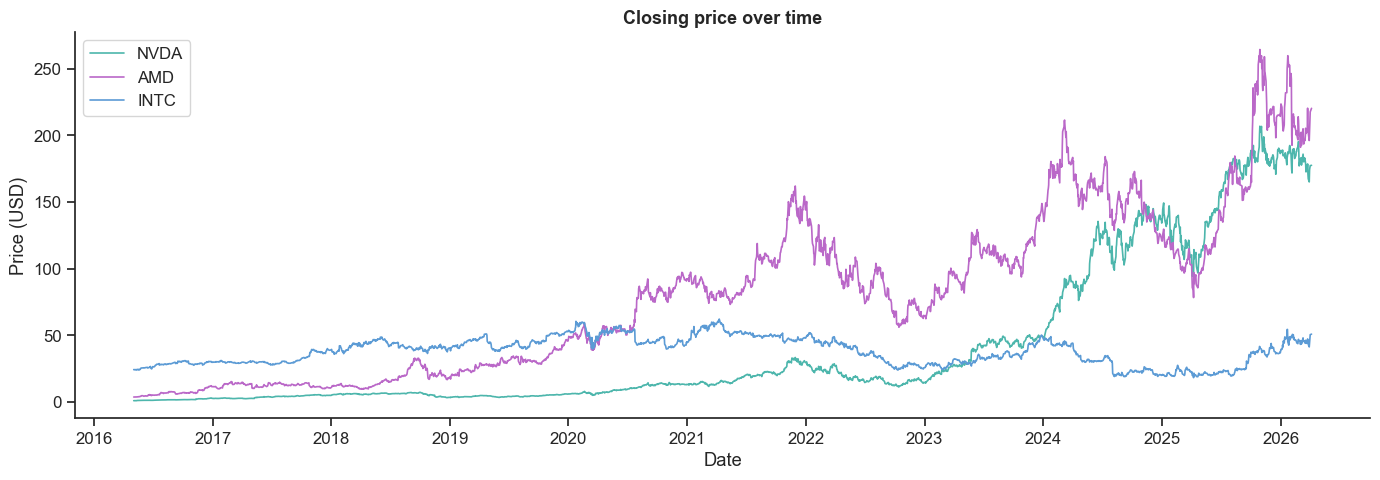

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

for ticker, color in company_colors.items():
    subset = df_final[df_final["ticker"] == ticker].copy()
    subset["date"] = pd.to_datetime(subset["date"])
    ax.plot(subset["date"], subset["close"], label=ticker, color=color, linewidth=1.2)

ax.set_title("Closing price over time", fontsize=13, fontweight="bold")
ax.set_ylabel("Price (USD)")
ax.set_xlabel("Date")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

NVIDIA and AMD show dramatically different growth trajectories compared to Intel. NVIDIA remained flat until 2023 when it surged exponentially driven by AI demand, while AMD grew steadily from 2019 with a peak in 2021–2022. Intel, by contrast, peaked around 2020–2021 and has been in a sustained decline since, reflecting its loss of competitive position in the semiconductor market.

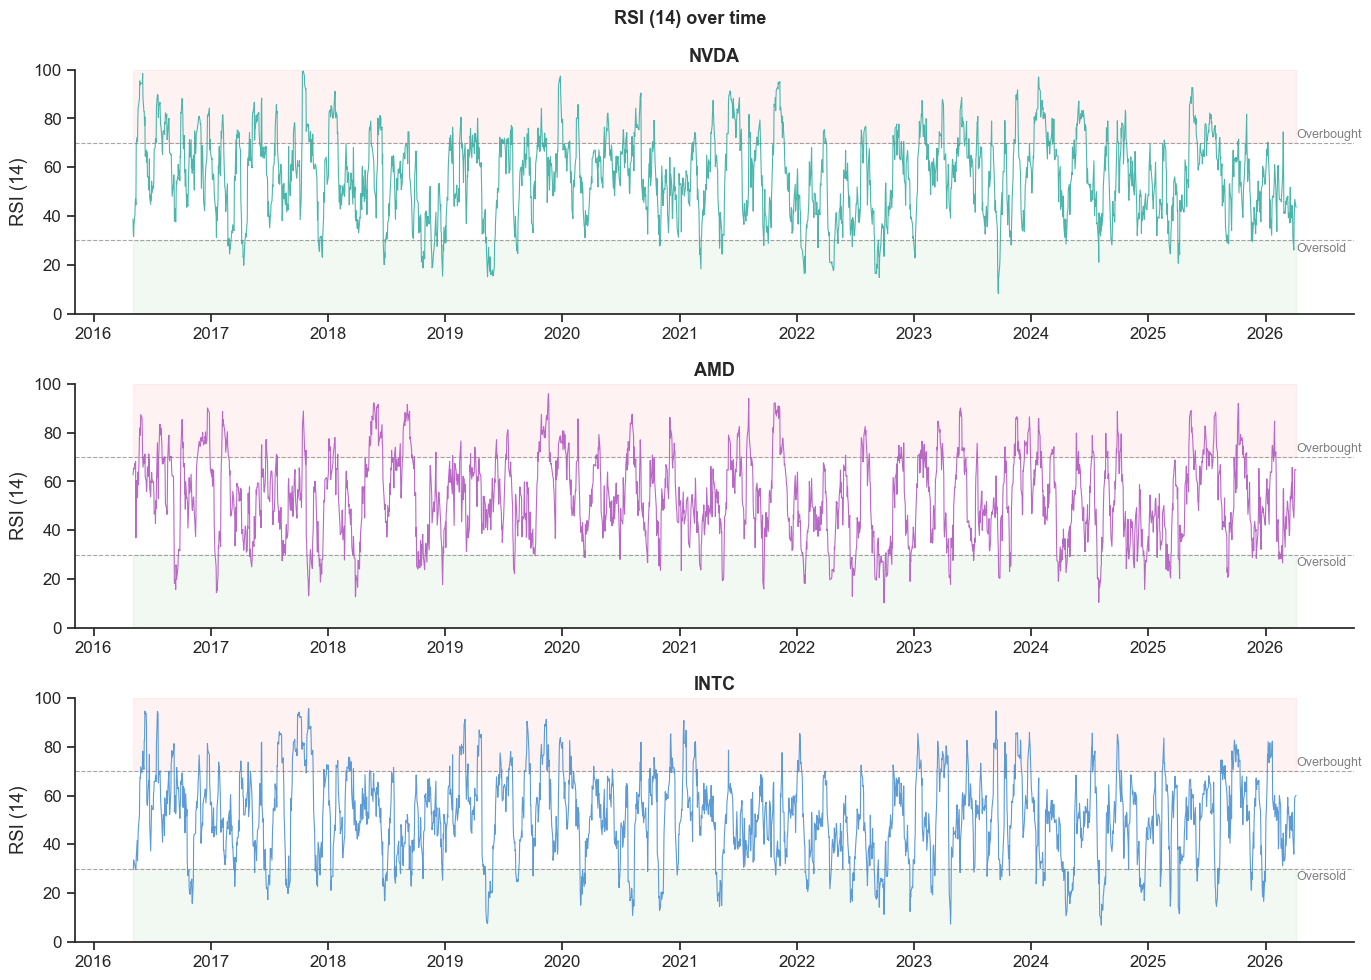

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (ticker, color) in zip(axes, company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker].copy()
    subset["date"] = pd.to_datetime(subset["date"])
    
    ax.plot(subset["date"], subset["rsi_14"], color=color, linewidth=0.8)
    ax.axhline(70, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.axhline(30, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.fill_between(subset["date"], 70, 100, alpha=0.05, color="red")
    ax.fill_between(subset["date"], 0, 30, alpha=0.05, color="green")
    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_ylabel("RSI (14)")
    ax.set_ylim(0, 100)
    ax.text(subset["date"].iloc[-1], 71, "Overbought", fontsize=9, color="gray", va="bottom")
    ax.text(subset["date"].iloc[-1], 29, "Oversold", fontsize=9, color="gray", va="top")
    sns.despine(ax=ax)

fig.suptitle("RSI (14) over time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

RSI(14) values for all three companies regularly oscillate between overbought (>70) and oversold (<30) levels, indicating recurring momentum shifts throughout the analyzed period. Most observations remain within the neutral range, suggesting that extreme market conditions are relatively short-lived.

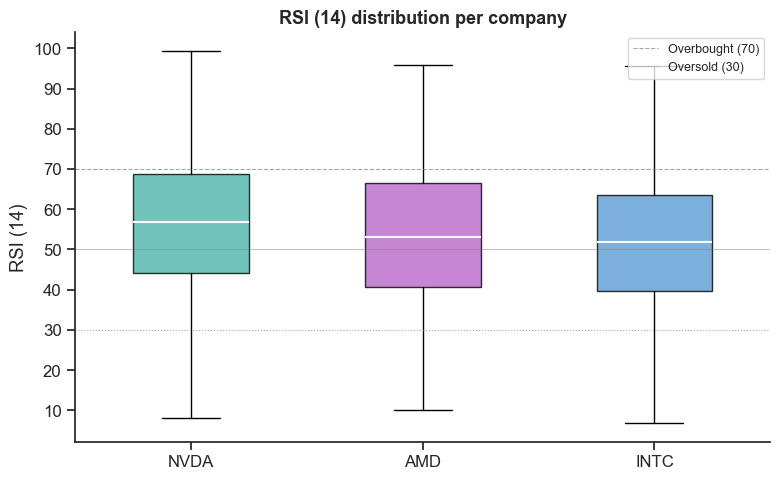

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

data = [df_final[df_final["ticker"] == ticker]["rsi_14"].dropna() 
        for ticker in ["NVDA", "AMD", "INTC"]]

bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=1.5))

for patch, color in zip(bp["boxes"], company_colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.axhline(70, color="gray", linewidth=0.8, linestyle="--", alpha=0.7, label="Overbought (70)")
ax.axhline(30, color="gray", linewidth=0.8, linestyle=":",  alpha=0.7, label="Oversold (30)")
ax.axhline(50, color="gray", linewidth=0.5, alpha=0.7)
ax.set_xticks([1, 2, 3])
ax.set_yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.set_xticklabels(["NVDA", "AMD", "INTC"])
ax.set_ylabel("RSI (14)")
ax.set_title("RSI (14) distribution per company", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

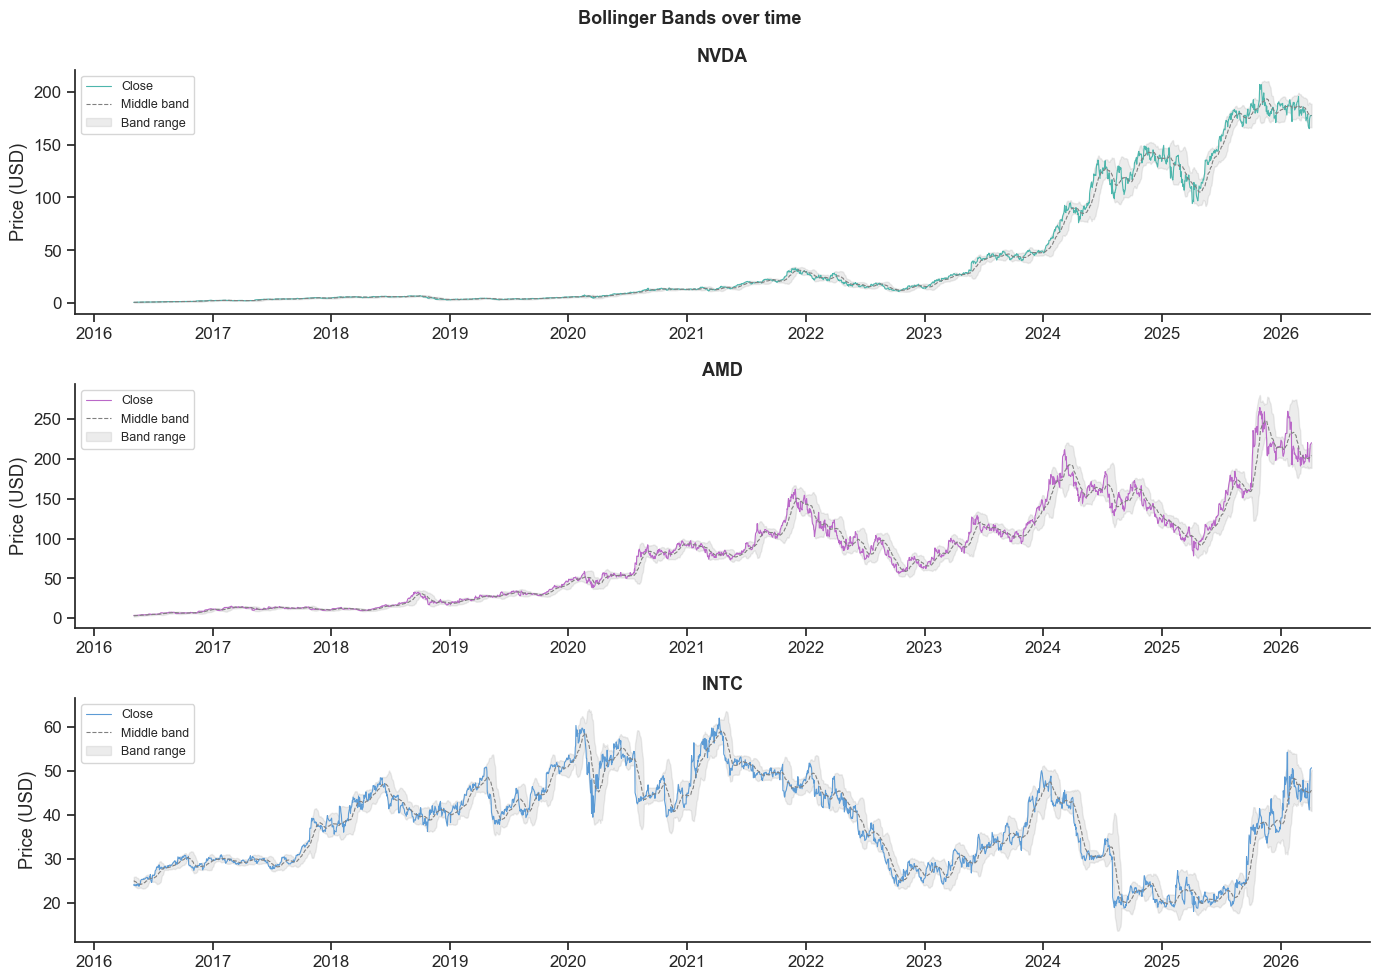

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (ticker, color) in zip(axes, company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker].copy()
    subset["date"] = pd.to_datetime(subset["date"])

    ax.plot(subset["date"], subset["close"], color=color, linewidth=0.8, label="Close")
    ax.plot(subset["date"], subset["bb_middle"], color="gray", linewidth=0.8, linestyle="--", label="Middle band")
    ax.fill_between(subset["date"], subset["bb_lower"], subset["bb_upper"],
                    alpha=0.15, color="gray", label="Band range")

    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (USD)")
    ax.legend(fontsize=9, loc="upper left")
    sns.despine(ax=ax)

fig.suptitle("Bollinger Bands over time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Bollinger Bands reflect the diverging trajectories of the three companies. 
NVIDIA and AMD show narrow bands in the early period that widen significantly 
from 2023 and 2020 respectively, with price frequently touching the upper band, 
signaling strong bullish momentum. Intel, by contrast, exhibits stable band width 
throughout the entire period with no clear directional breakout, consistent with 
its prolonged sideways-to-downward price trend.

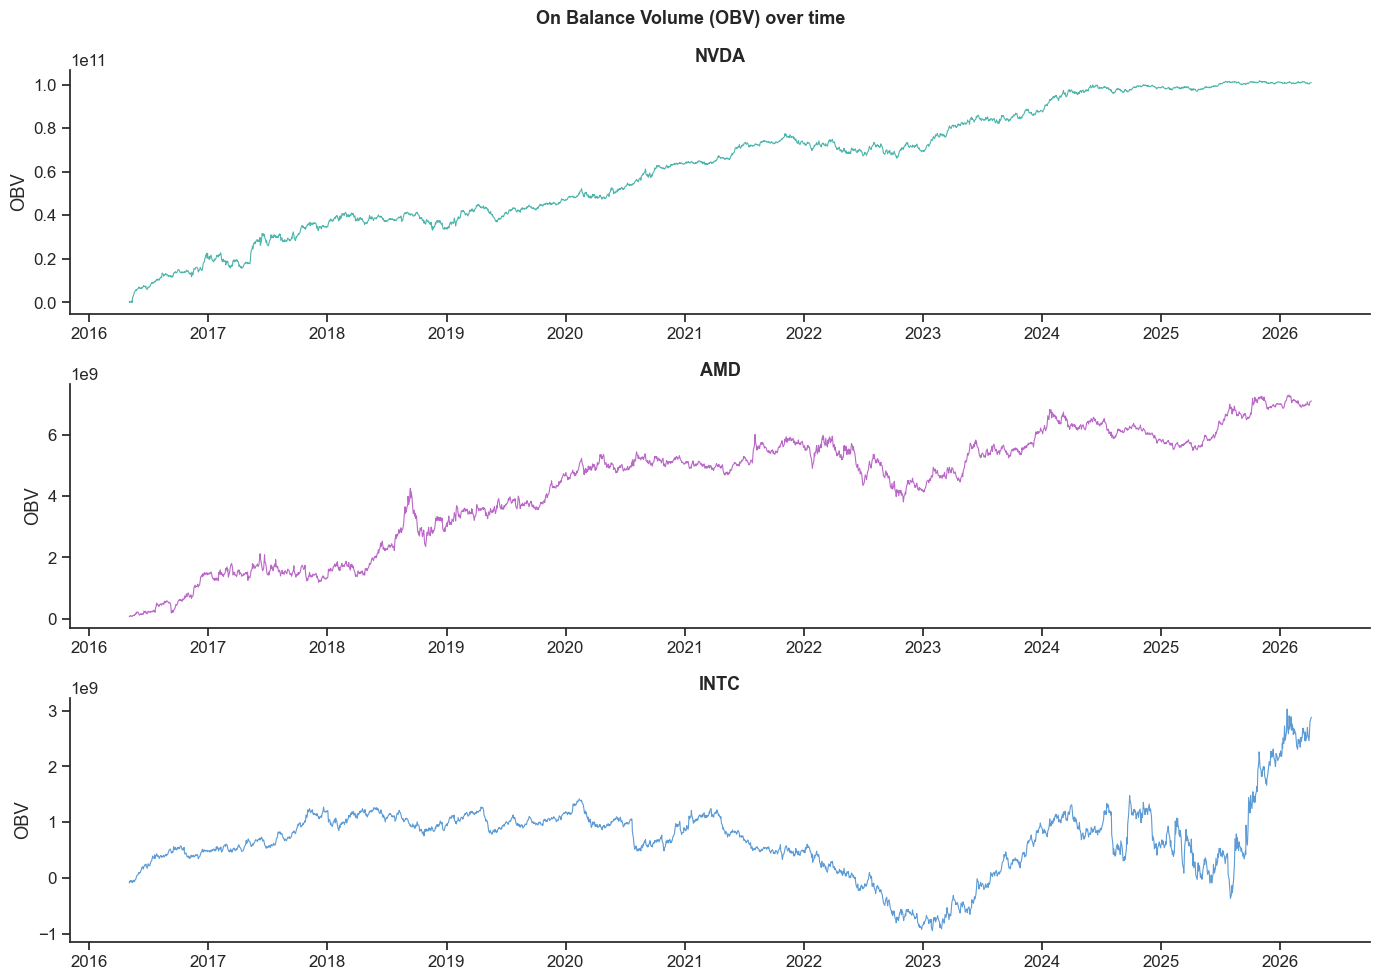

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (ticker, color) in zip(axes, company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker].copy()
    subset["date"] = pd.to_datetime(subset["date"])
    
    ax.plot(subset["date"], subset["obv"], color=color, linewidth=0.8)
    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_ylabel("OBV")
    sns.despine(ax=ax)

fig.suptitle("On Balance Volume (OBV) over time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

OBV confirms the price trends with buying pressure signals. NVIDIA shows a consistently rising OBV throughout the entire period, indicating persistent accumulation even during price stagnation before 2023, suggesting institutional buying ahead of the AI boom. AMD follows a similar upward trend with a notable acceleration from 2019. Intel's OBV tells the opposite story — after rising until 2021, it turns sharply negative through 2022–2023, indicating sustained distribution and selling pressure, before partially recovering in 2025–2026.

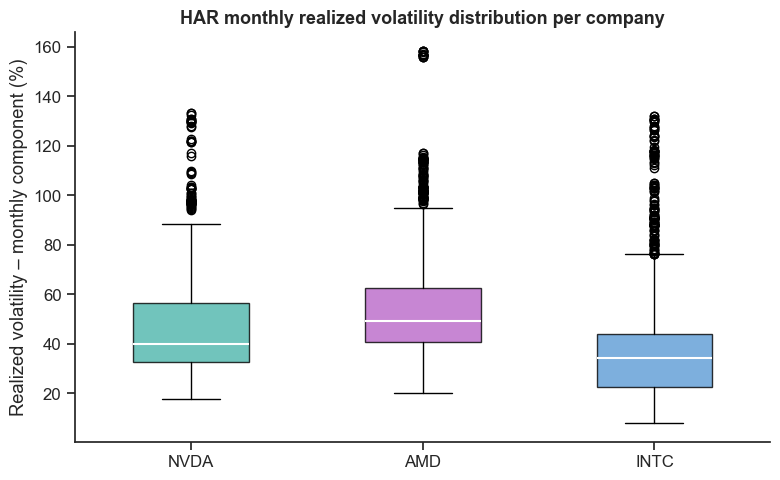

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

data = [df_final[df_final["ticker"] == ticker]["rv_monthly"]
        for ticker in ["NVDA", "AMD", "INTC"]]

bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=1.5))

for patch, color in zip(bp["boxes"], company_colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["NVDA", "AMD", "INTC"])
ax.set_ylabel("Realized volatility – monthly component (%)")
ax.set_title("HAR monthly realized volatility distribution per company",
             fontsize=13, fontweight="bold")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [22]:
for ticker in ["NVDA", "AMD", "INTC"]:
    subset = df_final[df_final["ticker"] == ticker][["date", "rv_monthly"]].copy()

    Q1 = subset["rv_monthly"].quantile(0.25)
    Q3 = subset["rv_monthly"].quantile(0.75)
    IQR = Q3 - Q1
    threshold = Q3 + 1.5 * IQR

    outliers = subset[subset["rv_monthly"] > threshold].sort_values("rv_monthly", ascending=False)

    print(f"\n{ticker} — top 3 highest rv_monthly days (outliers above {threshold:.1f}%):")
    print(outliers.head(3)[["date", "rv_monthly"]].to_string(index=False))


NVDA — top 3 highest rv_monthly days (outliers above 92.5%):
      date  rv_monthly
2020-04-08  133.366812
2020-04-07  133.134809
2020-03-25  132.299525

AMD — top 3 highest rv_monthly days (outliers above 95.8%):
      date  rv_monthly
2016-05-04  158.529562
2016-05-05  158.529562
2016-05-06  158.401589

INTC — top 3 highest rv_monthly days (outliers above 76.2%):
      date  rv_monthly
2020-04-07  132.111485
2020-04-08  131.918210
2020-03-30  130.996176


AMD exhibits the highest median volatility, followed by NVIDIA and Intel. 
All three companies show outliers in the upper tail, which correspond to 
identifiable market events. For NVIDIA and Intel, 
peak volatility days cluster around March–April 2020, coinciding with the 
COVID-19 market crash. For AMD, the highest volatility days occur in May 2016, 
corresponding to the announcement of the Zen architecture.

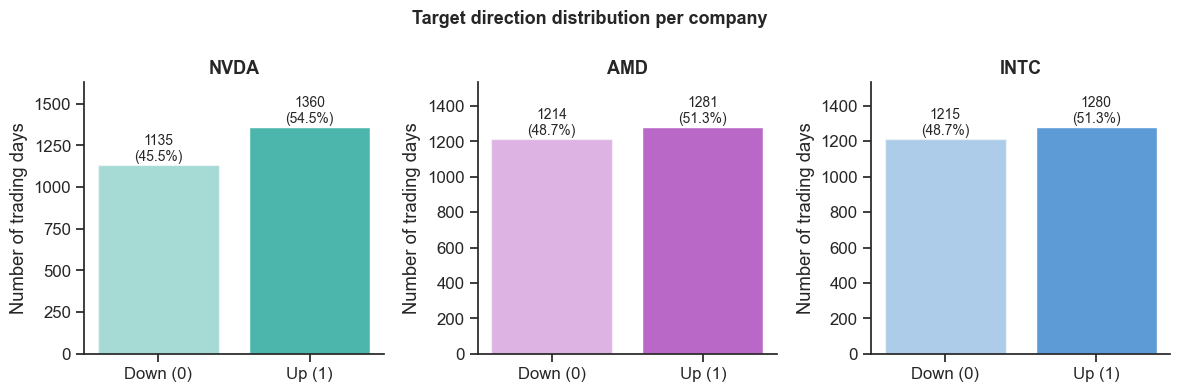

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (ticker, color) in zip(axes, company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker]
    counts = subset["target_direction"].value_counts().sort_index()

    bars = ax.bar(["Down (0)", "Up (1)"], counts.values,
                  color=[color, color], edgecolor="white")
    bars[0].set_alpha(0.5)
    bars[1].set_alpha(1.0)

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                f"{val}\n({100 * val / len(subset):.1f}%)",
                ha="center", va="bottom", fontsize=10)

    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of trading days")
    ax.set_ylim(0, counts.max() * 1.2)
    sns.despine(ax=ax)

fig.suptitle("Target direction distribution per company", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Target direction** is approximately balanced across all three companies. NVIDIA shows 
a slight upward bias (54.5% Up vs. 45.5% Down), while AMD and Intel are nearly 
perfectly balanced at 51.3% vs. 48.7%. This balance is expected and reflects a 
well-known property of stock markets over long horizons, prices tend to rise slightly 
more often than they fall, consistent with the long-term positive equity premium. 
The near-perfect balance means that no class weighting or resampling techniques 
are required for classification modeling.

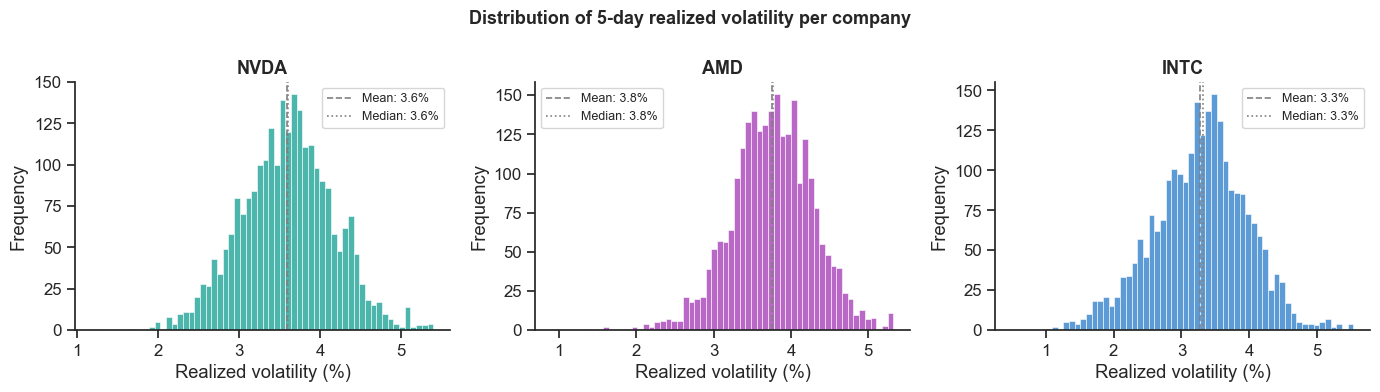

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (ticker, color) in zip(axes, company_colors.items()):
    subset = df_final[df_final["ticker"] == ticker]["target_log_volatility_5d"].dropna()
    ax.hist(subset, bins=60, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(subset.mean(), color="gray", linewidth=1.2, linestyle="--",
               label=f"Mean: {subset.mean():.1f}%")
    ax.axvline(subset.median(), color="gray", linewidth=1.2, linestyle=":",
               label=f"Median: {subset.median():.1f}%")
    ax.set_title(ticker, fontsize=13, fontweight="bold")
    ax.set_xlabel("Realized volatility (%)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.suptitle("Distribution of 5-day realized log volatility per company",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Final Dataset

The final dataset contains daily market data, technical indicators, and prediction targets for NVIDIA, AMD, and Intel. Rows containing missing values generated by rolling-window calculations and future volatility target construction were removed

In [23]:
OUTPUT_PATH = f"{OUTPUT_DIR}/yahoo_finance.csv"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("yahoo_finance")

with mlflow.start_run(run_name="yahoo_finance_download"):

    mlflow.log_param("tickers",    ", ".join(TICKERS))
    mlflow.log_param("start_date", START_DATE)
    mlflow.log_param("end_date",   END_DATE)
    mlflow.log_param("n_features", len(df_final.columns))
    mlflow.log_metric("total_rows", len(df_final))
    mlflow.log_param("volatility_horizon_days", 10)

    for ticker in TICKERS:
        subset = df_final[df_final["ticker"] == ticker]

        mlflow.log_metric(f"rows_{ticker}", len(subset))
        mlflow.log_metric(
            f"direction_positive_{ticker}",
            subset["target_direction"].sum()
        )
        mlflow.log_metric(
            f"direction_negative_{ticker}",
            (subset["target_direction"] == 0).sum()
        )
        mlflow.log_metric(
            f"volatility_mean_{ticker}",
            subset["target_log_volatility_5d"].mean()
        )
        mlflow.log_metric(
            f"volatility_std_{ticker}",
            subset["target_log_volatility_5d"].std()
        )

    df_final.to_csv(OUTPUT_PATH, index=False)

    print(f"Dataset saved : {OUTPUT_PATH}")
    print("MLflow run    : completed")

2026/06/24 14:40:02 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



Dataset saved : datasets/processed/yahoo_finance.csv
MLflow run    : completed
